<a href="https://colab.research.google.com/github/Kaviyarasu71/Data-science-GH1040793/blob/main/DataVisualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. **Introduction**

Freelancing has grown to be a crucial part of the global digital economy, giving professionals flexible work options and allowing companies to access talent anywhere in the world. Making trained hiring decisions wants an understanding of trends in freelancer earnings, skills, and experience offered the increasing dependency on freelance platforms.

In order to find valuable insights that may help companies in optimizing their hiring practices, this project examines a global dataset of freelancers.

## 2. Business **Context**

The client for this analysis is a company looking to optimise its freelance hiring strategy. Specifically, the company wants to understand:

Which areas provide the best value in terms of price and quality?

What skills have the greatest demand after in the freelance industry?

How experience affects the performance and income of freelancers?

The following insights from this analysis will benefit the business:

* Cut down on hiring expenses

* Enhance the selection of talent

* When working with freelance workers, maximize return on investment.

## 3. Dataset **Description**

The dataset used in this project contains information about freelancers from various countries around the world.

Key Variables:

* Country – Location of the freelancer

* Skill – Primary expertise of the freelancer

* Earnings – Income generated by the freelancer

* Experience (years) – Years of professional experience


**Data Characteristics**

* Mix of categorical and numerical variables


* Represents a diverse global workforce


* Contains potential inconsistencies and missing values

This dataset provides a strong foundation for analysing global freelance trends and behaviours.

**Loading dataset**

In [94]:

import pandas as pd

df = pd.read_csv("global_freelancers_raw.csv")
df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


## 4. Data **Exploration**

Initial exploration of the dataset tells that  several important characteristics:

However,  a number of problems with data quality were found:

* Missing values in key columns

* Possible outliers in earnings

* Inconsistent formatting in categorical variables

Understanding these characteristics is essential before proceeding to analysis, as poor data quality can lead to false conclusion.

In [95]:

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


,0
freelancer_ID,0
name,0
gender,0
age,30
country,0
language,0
primary_skill,0
years_of_experience,51
hourly_rate (USD),94
rating,101


The dataset contains missing values and potential outliers that need cleaning.

## 5. Data **Cleaning**

These steps improves the quality and consistency of the dataset, gives meaningful insights to be gained.

In [96]:
print(df.columns)

Index(['freelancer_ID', 'name', 'gender', 'age', 'country', 'language',
       'primary_skill', 'years_of_experience', 'hourly_rate (USD)', 'rating',
       'is_active', 'client_satisfaction'],
      dtype='object')


In [97]:
 #   clean coloumn names

df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)

#   Defining Key Variables

country_col = 'country'
earnings_col = 'hourly_rate (usd)'
skill_col = 'primary_skill'
exp_col = 'years_of_experience'

#   Validating Required Columns

for col_name in [country_col, earnings_col, skill_col, exp_col]:
    if col_name not in df.columns:
        raise ValueError(f"Critical column '{col_name}' not found in DataFrame after cleaning names.")

print(country_col, earnings_col, skill_col, exp_col)


#   Cleaning Earnings Data

df[earnings_col] = df[earnings_col].astype(str).str.replace(r'[$, usd]', '', regex=True)
df[earnings_col] = pd.to_numeric(df[earnings_col], errors='coerce')

#   Handling Missing Values

df = df.dropna(subset=[earnings_col])

#   Removing Outliers

df = df[df[earnings_col] < df[earnings_col].quantile(0.99)]
df = df.drop_duplicates().reset_index(drop=True)

Columns: Index(['freelancer_id', 'name', 'gender', 'age', 'country', 'language',
       'primary_skill', 'years_of_experience', 'hourly_rate (usd)', 'rating',
       'is_active', 'client_satisfaction'],
      dtype='object')
country hourly_rate (usd) primary_skill years_of_experience


## 6. Insight 1: Top Countries by Freelancer Earnings

/tmp/ipykernel_601/1133369555.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_earnings.index, y=country_earnings.values, palette='viridis')


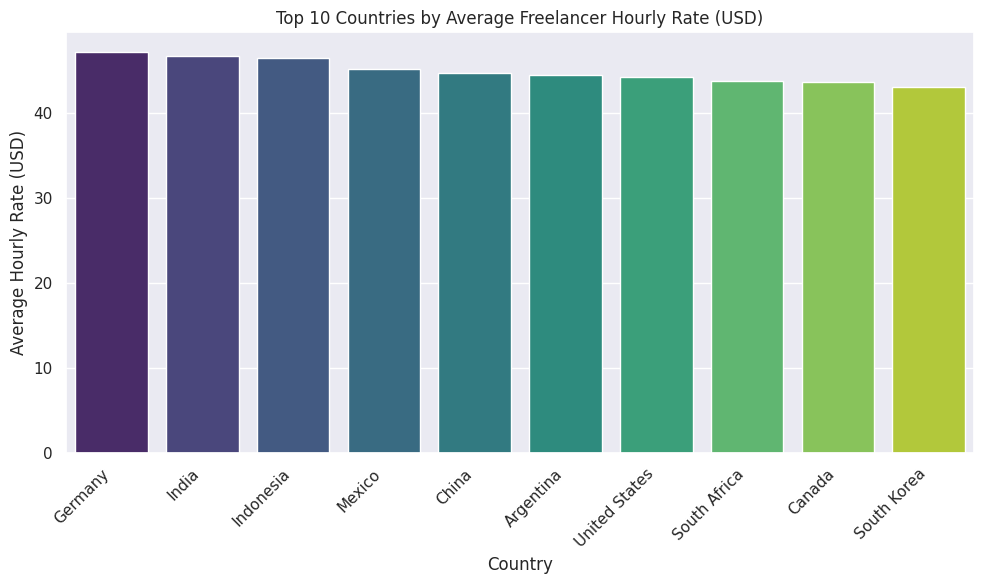

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns


if not df[earnings_col].empty:
    country_earnings = df.groupby(country_col)[earnings_col].mean().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=country_earnings.index, y=country_earnings.values, palette='viridis')
    plt.title("Top 10 Countries by Average Freelancer Hourly Rate (USD)")
    plt.xlabel("Country")
    plt.ylabel("Average Hourly Rate (USD)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'earnings_col' is empty after cleaning.")

**Explanation**

The chart shows the average earnings of freelancers across different countries. It is clear that certain countries consistently report higher earnings compared to others, indicating strong regional differences in the freelance market.

### Business Importance

 Companies can strategically choose freelancers based on budget

 * High-budget projects -> hire from high earning countries

 * Cost-sensitive tasks -> hire from lower cost regions



## **7. Insight 2: Most Popular Skills**

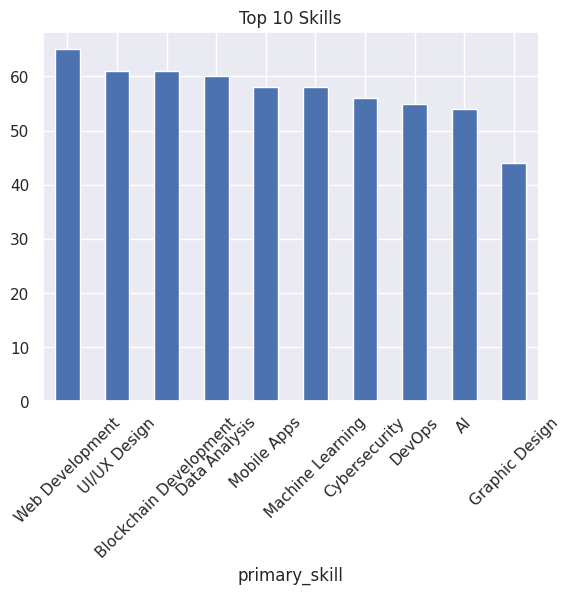

In [99]:
df['primary_skill'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Skills")
plt.xticks(rotation=45)
plt.show()

**Explanation**

The chart highlights the most common skills among freelancers. A small number of skills dominate the market, indicating high demand in specific areas.

 **Business Importance**

 Understanding popular skills allows businesses to lead their hiring strategies with market demand and ensure they are targeting relevant expertise Skills such as programming, design, and data analysis are in high demand  tells  current industry trends

## **8. Insight 3: Earnings vs Experience**

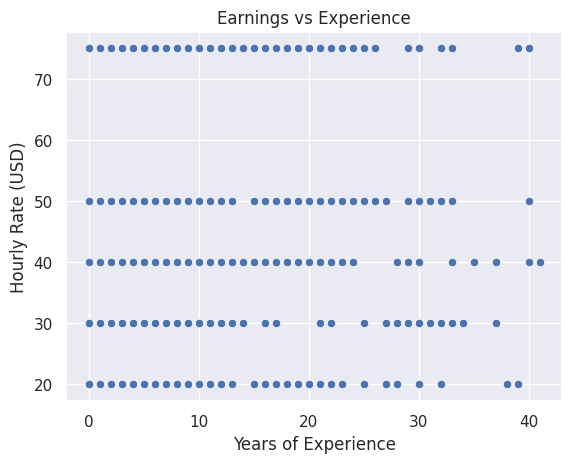

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=exp_col, y=earnings_col, data=df)
plt.title("Earnings vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Hourly Rate (USD)")
plt.show()

**Explanation**

The scatter plot shows a positive relationship between experience and earnings. As experience increases, earnings should need  to increase as well.


**Business Importance**

More experience leads to higher earnings. Hiring experienced freelancers can:


1. Improve project quality
2. Reduce risk
3. Increase efficiency


However, this comes at a higher cost.

## **9. Insight 4: Highest Paying Skills**

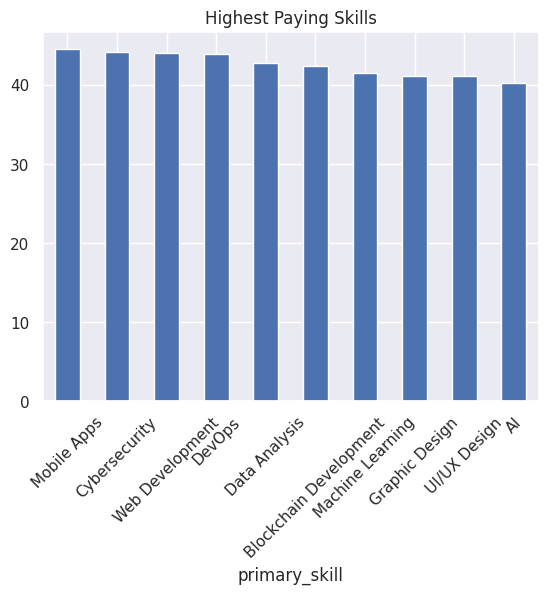

In [101]:
skill_earnings = df.groupby(skill_col)[earnings_col].mean().sort_values(ascending=False).head(10)

skill_earnings.plot(kind='bar')
plt.title("Highest Paying Skills")
plt.xticks(rotation=45)
plt.show()

**Explanation**

The chart shows that certain specialised skills creates significantly higher earnings compared to others.

**Business Importance**

Specialised and technical skills (e.g... software development, data science) command higher pay due to  rarity and difficulty .

## **10. Insight 5: Freelancer Distribution by Country**

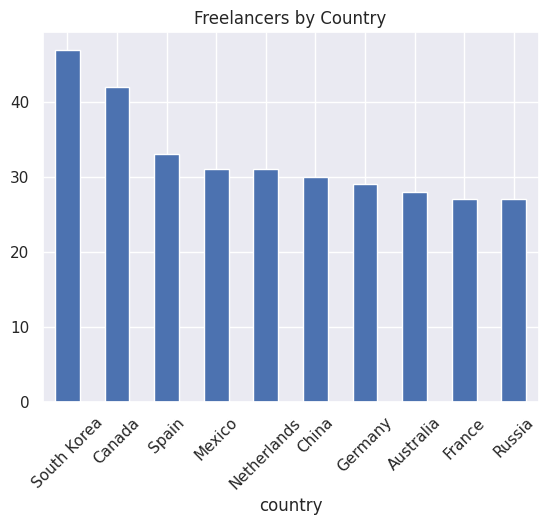

In [113]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Freelancers by Country")
plt.xticks(rotation=45)
plt.show()

**Explanation**

The chart explains the number of freelancers in each country. Some countries dominate the freelance workforce.

**Business Importance**

A big freelancer base increases competition  which can lead to more competitive pricing and greater hiring opportunity.

## **11. Insight 6: Experience Distribution**

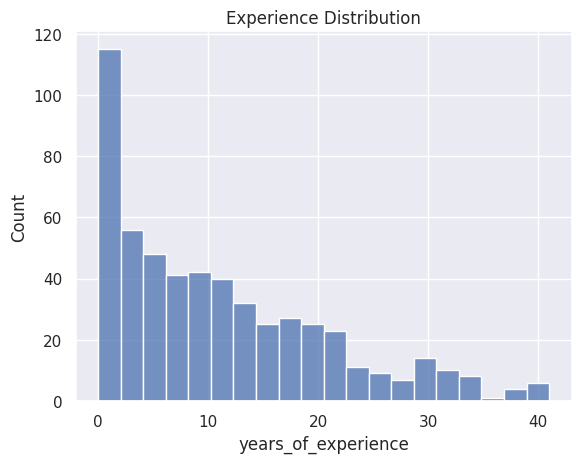

In [116]:
sns.histplot(df[exp_col], bins=20)
plt.title("Experience Distribution")
plt.show()

**Explanation**

The majority of freelancers comes within a mid level experience range tells that the market is dominated by middle experienced professionals rather than beginners or experts.

**Business Importance**

This creates an opportunity for businesses to access reasonably skilled freelancers at moderate costs.

Majority fall between beginner and expert levels.

* Mid-level freelancers offer a balance between cost and expertise

* Ideal for most business needs

## **12. Insight 7: Earnings Distribution**

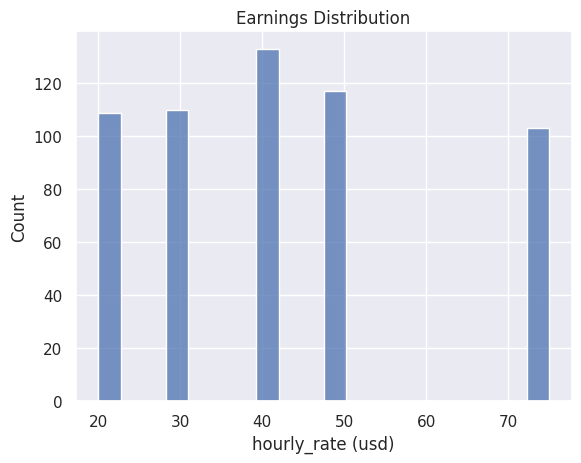

In [119]:
sns.histplot(df[earnings_col], bins=20)
plt.title("Earnings Distribution")
plt.show()

**Explanation**

the area around '60' appears empty , it means that there are very few or no freelancers in our dataset whose hourly rate falls within the bin that includes 60.

The distribution of earnings is highly skewed, with a small number of freelancers earning significantly more than the majority.

**Business Importance**

This insight suggests that not all freelancers deliver equal value, and identifying top performers is critical for business success.

# **13. Conclusion**

## Strengths of Analysis

* Clear insights from multiple viewpoint

* Clean and structured pipeline

* Business focused storytelling


## Limitations

* Dataset may not represent all freelancers globally

* Missing data which leads to less accuracy

* No time based trends



## Key Insights

* Country and skill mostly affect earnings

* Experience strongly relates  with income

* Market is dominated by a less key skills



## Recommendations to Improve

* Hire strategically by region

* Balance cost vs quality

* Tech and data roles provide highest ROI

* Invest in experienced freelancers is to avoid mistakes which leads to  Higher cost but better output

* Avoid dependency on specific countries .




## Citation Link

https://www.kaggle.com/datasets/urvishahir/global-freelancers-raw-dataset?resource=download